# 🏠 House Price Prediction

## Introduction

House Price Prediction is a Machine Learning Regression project.

The main objective of this project is to predict the price of a
house using different features related to the property.

In this project, we will perform data analysis, visualization,
data preprocessing, model training, prediction, and model evaluation.

### Machine Learning Type
Regression

### Target Variable
House Price

## Problem Statement

House prices depend on several factors such as the size of the
property, number of rooms, quality of the house, location,
garage facilities, and other features.

The objective of this project is to analyze these factors and
build a Regression Machine Learning model that can predict the
price of a house.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

The dataset is loaded using Pandas `read_csv()`.

The `head()` function displays the first five rows of the dataset.

This helps us understand the initial structure and values of
the dataset.

In [2]:
data = pd.read_csv("house_prices_practice.csv")

data.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


## Dataset Shape

The `shape` function shows the number of rows and columns
present in the dataset.

- Rows → Number of house records
- Columns → Number of features

This helps us understand the size of our dataset.

In [3]:
data.shape

(300, 10)

## Dataset Columns

The `columns` attribute displays all the column names in the dataset.

These columns represent different features of the houses.

We will use these features to understand the factors related
to house prices.

In [4]:
data.columns

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')

## Dataset Information

The `info()` function gives information about the dataset.

It shows:

- Number of rows
- Column names
- Number of non-null values
- Data types of each column

This step helps us identify numerical and categorical columns
and understand whether any values are missing.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


## Statistical Summary

The `describe()` function provides statistical information
about numerical columns.

It includes:

- Count
- Mean
- Standard deviation
- Minimum value
- 25% percentile
- 50% percentile
- 75% percentile
- Maximum value

This helps us understand the distribution and range of
the numerical features.

In [6]:
data.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


## Checking Missing Values

Missing values are empty or unavailable values in the dataset.

We use `isnull().sum()` to find the number of missing values
in each column.

Missing values should be handled before training a
Machine Learning model.

In [7]:
data.isnull().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

## Checking Duplicate Records

Duplicate records are repeated rows in the dataset.

We use `duplicated().sum()` to find the total number of
duplicate rows.

Removing unnecessary duplicate records can improve the
quality of our analysis.

In [8]:
data.duplicated().sum()

np.int64(0)

## Displaying Duplicate Records

The previous step tells us how many duplicate rows exist.

Here, we display the duplicate rows so that we can inspect
them before deciding whether they need to be removed.

In [9]:
data[data.duplicated()]

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice


## Data Types

The `dtypes` attribute shows the data type of every column.

Common data types include:

- int → Integer values
- float → Decimal values
- object → Text or categorical values

Understanding data types is important before preprocessing
the dataset for Machine Learning.

In [10]:
data.dtypes

Id              int64
OverallQual     int64
GrLivArea       int64
GarageCars      int64
TotalBsmtSF     int64
YearBuilt       int64
FullBath        int64
BedroomAbvGr    int64
LotArea         int64
SalePrice       int64
dtype: object

## Numerical and Categorical Features

We separate the columns into two groups.

### Numerical Features

These contain numbers such as:

- Area
- Number of rooms
- Year
- Price

### Categorical Features

These contain categories or text values such as:

- Quality
- Location
- House type
- Garage type

This separation will help us during data preprocessing.

In [11]:
numerical_columns = data.select_dtypes(include=np.number).columns

categorical_columns = data.select_dtypes(include="object").columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')

Categorical Columns:
Index([], dtype='object')


# 📊 Exploratory Data Analysis

Exploratory Data Analysis helps us understand the dataset
using statistics and visualizations.

In this section, we will study:

- Distribution of house prices
- Numerical features
- Categorical features
- Relationships between features
- Correlation between variables

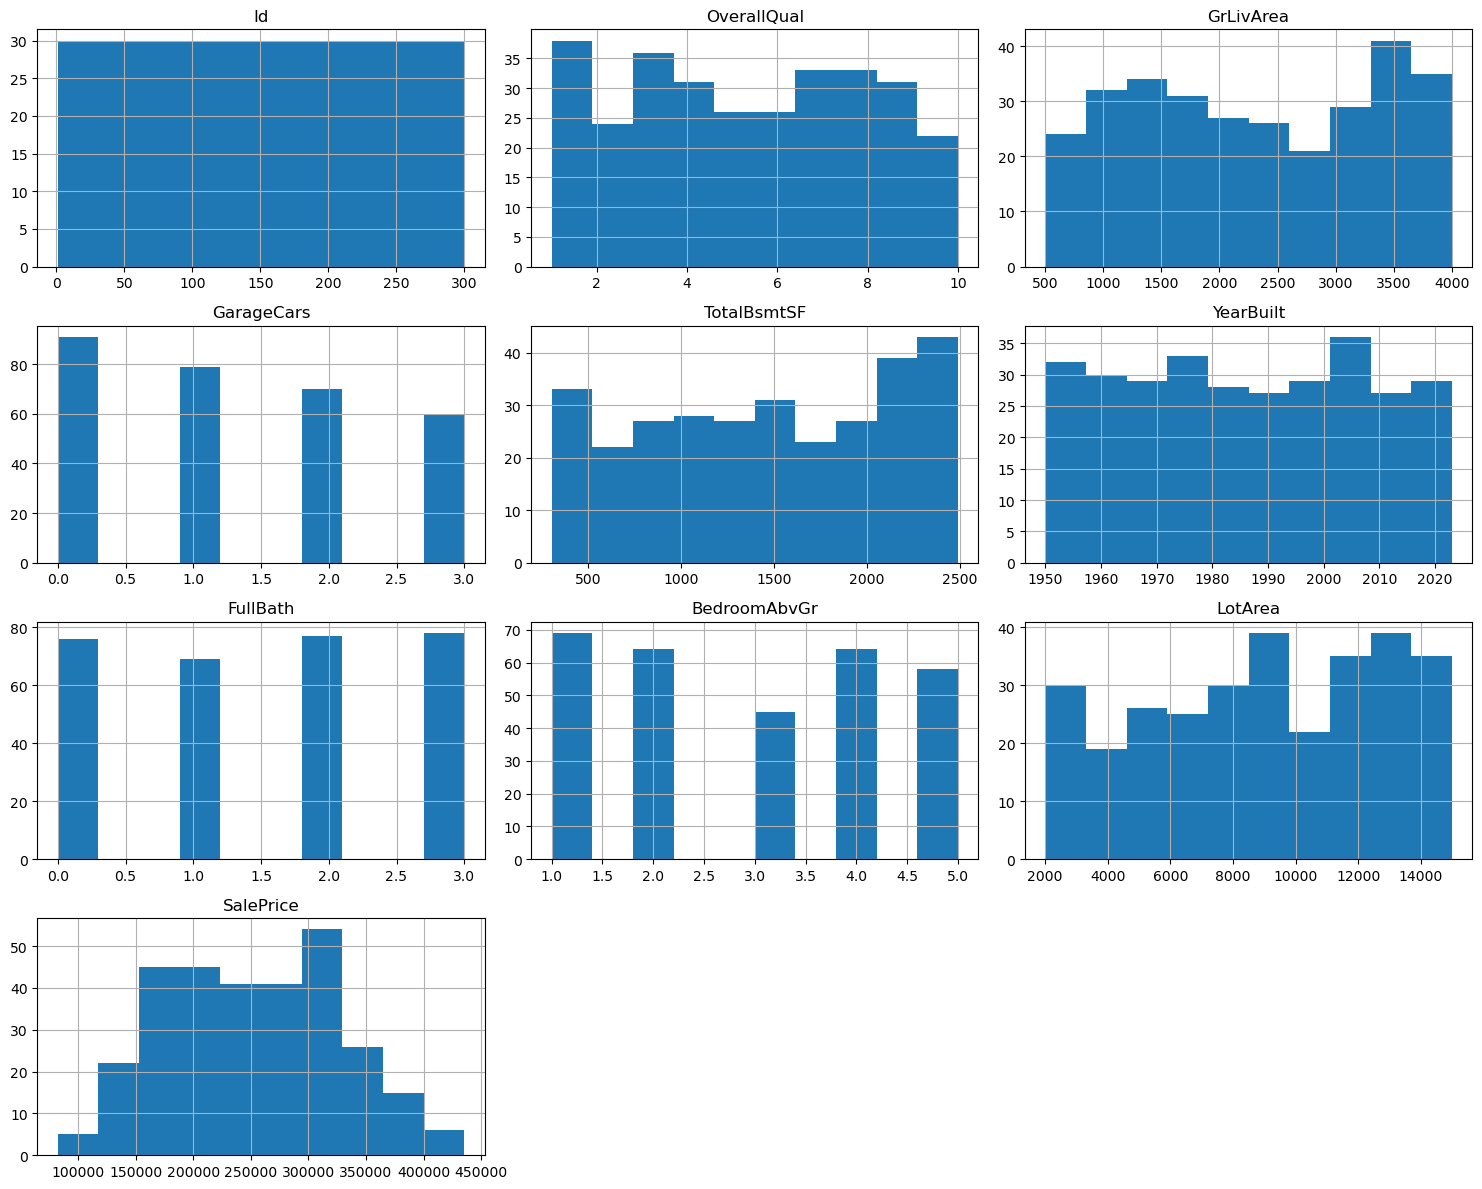

In [12]:
data.hist(figsize=(15, 12))

plt.tight_layout()
plt.show()

## Numerical Feature Distributions

Histograms help us understand how numerical values are
distributed.

They can show:

- Common value ranges
- Spread of values
- Skewness
- Possible unusual values

This gives us an initial understanding of the numerical data.

In [13]:
correlation = data.select_dtypes(include=np.number).corr()

correlation

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
Id,1.000000,-0.158700,0.050807,-0.008250,-0.024281,0.037105,0.064142,-0.006326,-0.060973,-0.025416
OverallQual,-0.158700,1.000000,-0.116413,-0.017138,0.008098,0.005990,-0.047619,-0.056594,-0.030605,0.352899
GrLivArea,0.050807,-0.116413,1.000000,0.056380,0.023471,0.032073,0.103215,-0.090480,-0.035433,0.745095
GarageCars,-0.008250,-0.017138,0.056380,1.000000,0.051605,-0.031599,0.125668,0.083287,-0.005316,0.351321
TotalBsmtSF,-0.024281,0.008098,0.023471,0.051605,1.000000,-0.050187,0.042792,-0.039197,-0.007753,0.250178
YearBuilt,0.037105,0.005990,0.032073,-0.031599,-0.050187,1.000000,0.020098,-0.040859,0.091507,0.222142
FullBath,0.064142,-0.047619,0.103215,0.125668,0.042792,0.020098,1.000000,0.037567,-0.061729,0.273731
BedroomAbvGr,-0.006326,-0.056594,-0.090480,0.083287,-0.039197,-0.040859,0.037567,1.000000,-0.000527,0.014113
LotArea,-0.060973,-0.030605,-0.035433,-0.005316,-0.007753,0.091507,-0.061729,-0.000527,1.000000,-0.038982
SalePrice,-0.025416,0.352899,0.745095,0.351321,0.250178,0.222142,0.273731,0.014113,-0.038982,1.000000


## Correlation Heatmap

Correlation measures the relationship between numerical variables.

The correlation value ranges from -1 to +1.

- +1 → Strong positive relationship
- 0 → Little or no linear relationship
- -1 → Strong negative relationship

The heatmap helps us identify which numerical features have
stronger relationships with the house price.

This information can be useful when selecting features
for our Regression model.

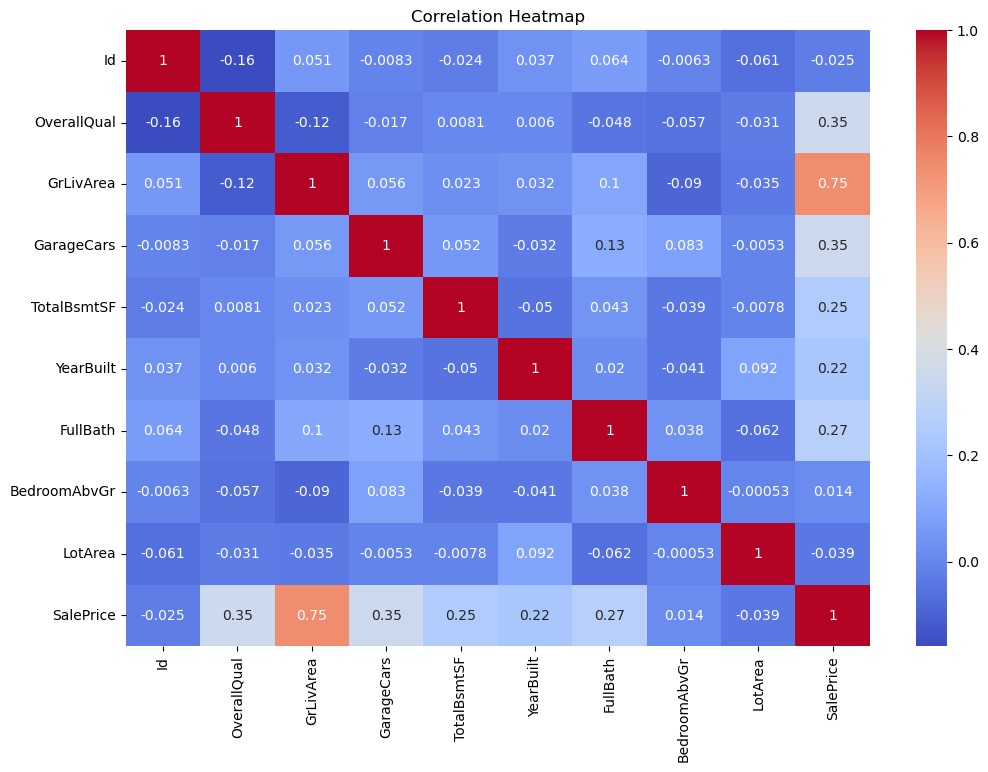

In [14]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Target Variable

In this project, our main objective is to predict the selling price
of a house.

The target variable is:

`SalePrice`

This is the value that our Machine Learning model will learn to predict.

All other selected columns will be used as input features.

## SalePrice Statistical Analysis

Here we analyze the statistical information of the target variable.

This helps us understand the minimum price, maximum price,
average price, and spread of house prices.

In [15]:
data["SalePrice"].describe()

count       300.000000
mean     252262.903333
std       74998.055214
min       82494.000000
25%      190355.250000
50%      251292.500000
75%      307105.000000
max      435291.000000
Name: SalePrice, dtype: float64

## House Price Distribution

The histogram shows how the house prices are distributed.

The KDE curve gives us an idea about the shape of the distribution.

This visualization helps us understand whether house prices are
concentrated in a particular range or spread across different values.

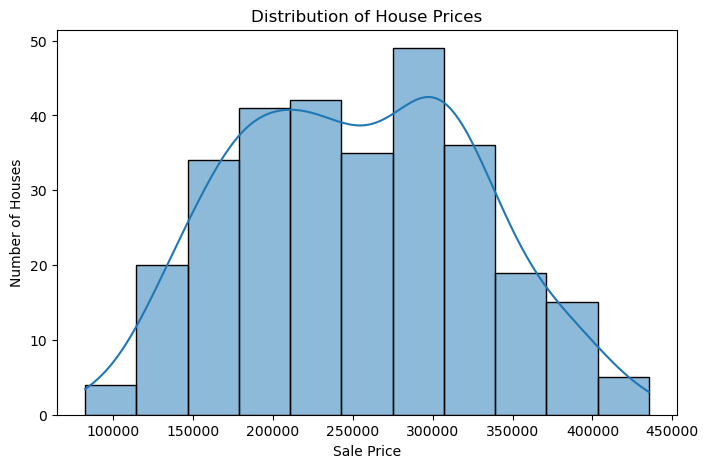

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(data["SalePrice"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

## Box Plot of House Prices

A box plot helps us identify the distribution of house prices
and possible outliers.

Outliers are values that are considerably different from
most of the other observations.

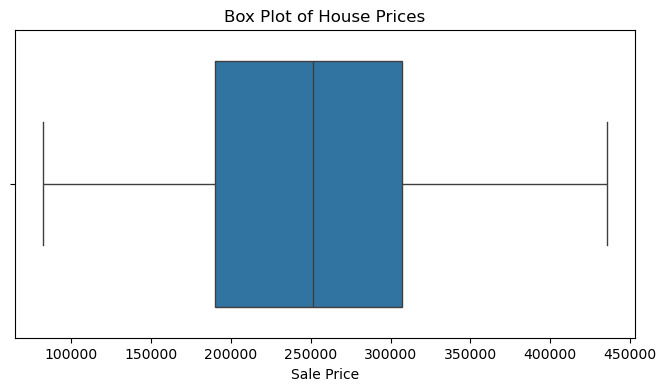

In [17]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=data["SalePrice"])

plt.title("Box Plot of House Prices")
plt.xlabel("Sale Price")

plt.show()

## Living Area vs House Price

This scatter plot shows the relationship between living area
and house price.

It helps us understand whether houses with larger living areas
generally have higher selling prices.

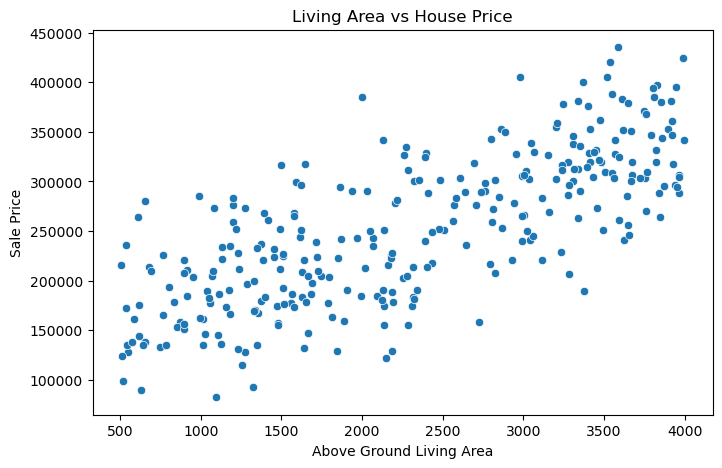

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=data["GrLivArea"],
    y=data["SalePrice"]
)

plt.title("Living Area vs House Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

## Overall Quality vs House Price

`OverallQual` represents the overall material and finish quality
of the house.

The box plot allows us to compare house prices across different
quality levels.

This helps us understand how house quality is related to
selling price.

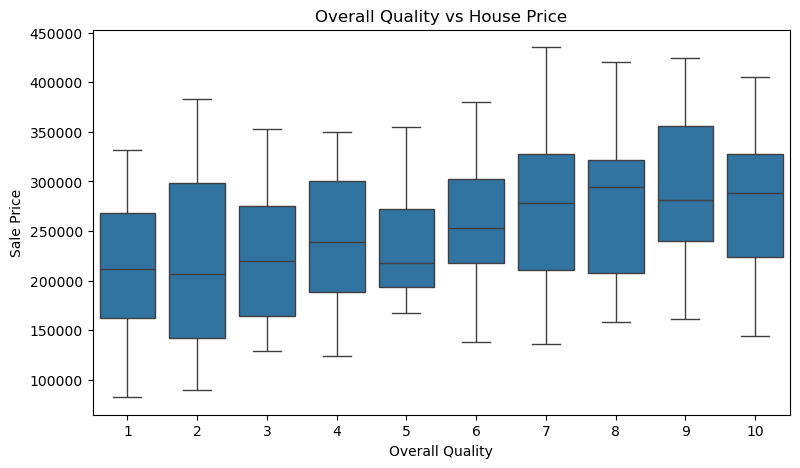

In [19]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    x=data["OverallQual"],
    y=data["SalePrice"]
)

plt.title("Overall Quality vs House Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

## Garage Capacity vs House Price

This visualization compares house prices based on garage capacity.

It helps us understand whether houses with larger garage capacity
have different selling prices.

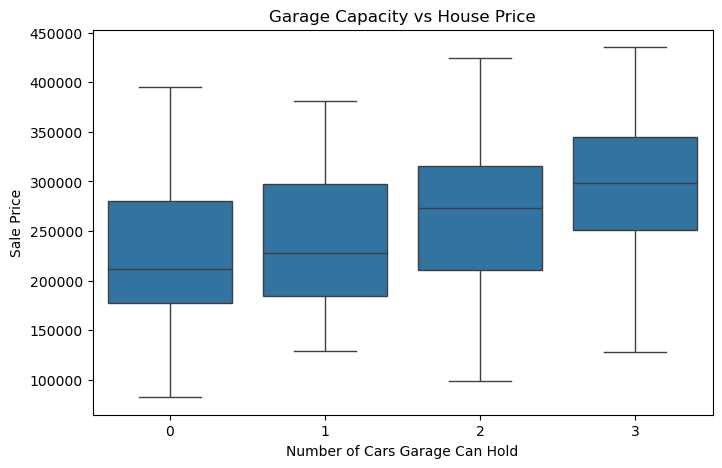

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=data["GarageCars"],
    y=data["SalePrice"]
)

plt.title("Garage Capacity vs House Price")
plt.xlabel("Number of Cars Garage Can Hold")
plt.ylabel("Sale Price")

plt.show()

# 🤖 Preparing Data for Machine Learning

Machine Learning models need input features and a target variable.

### Input Features (X)

We will use selected house features such as:

- Overall Quality
- Living Area
- Garage Capacity
- Total Basement Area
- Year Built
- Full Bathrooms
- Number of Rooms

### Target Variable (y)

Our target variable is:

`SalePrice`

In [23]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "FullBath",
    "BedroomAbvGr"
]

X = data[features]

y = data["SalePrice"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0            7       1560           0         1658       1969         2   
1            4       2827           2         1319       2012         3   
2            8       3920           0          841       2010         1   
3            5       3044           0         1058       1998         0   
4            7        801           1         2428       2020         0   

   BedroomAbvGr  
0             1  
1             4  
2             4  
3             4  
4             1  

Target:
0    177106
1    301044
2    360609
3    240556
4    193656
Name: SalePrice, dtype: int64


## Checking Missing Values in Selected Features

Before training the model, we need to make sure that
the selected features do not contain missing values.

Machine Learning algorithms generally cannot directly
work with missing values.

In [24]:
X.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
dtype: int64

## Handling Missing Values

We replace missing numerical values with the median
of their respective columns.

The median is useful because it is less affected by
extreme values than the mean.

In [25]:
X = X.fillna(X.median())

X.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
dtype: int64

## Train-Test Split

We divide the dataset into two parts.

### Training Data

The training data is used to teach the Machine Learning model.

### Testing Data

The testing data is used to check how well the trained model
works on unseen data.

We use:

- 80% → Training
- 20% → Testing

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 7)
Testing data: (60, 7)


# 📈 Linear Regression

Linear Regression is a supervised Machine Learning algorithm
used for predicting continuous numerical values.

In this project, the continuous value we want to predict is
the house selling price.

The model learns the relationship between the selected house
features and `SalePrice`.

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Making Predictions

After training the Linear Regression model, we use the testing
data to predict house prices.

The predicted values are stored in `y_pred`.

We can now compare these predicted prices with the actual
house prices.

In [28]:
y_pred = model.predict(X_test)

y_pred[:10]

array([238265.1158743 , 190625.18923704, 397820.07702214, 223394.72988624,
       135412.30126951, 180287.60647323, 282979.23503477, 204251.79937218,
       206624.37785062, 171361.96235283])

## Actual vs Predicted Prices

This table compares the actual house prices from the dataset
with the prices predicted by our model.

If the predicted price is close to the actual price,
the model has made a relatively accurate prediction for that house.

In [29]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,224163,238265.115874
1,203881,190625.189237
2,380236,397820.077022
3,211664,223394.729886
4,122139,135412.301270
5,180067,180287.606473
6,275810,282979.235035
7,209025,204251.799372
8,213952,206624.377851
9,154885,171361.962353


# 📊 Model Evaluation

We use four important metrics to evaluate our Regression model.

### 1. MAE — Mean Absolute Error

MAE represents the average absolute difference between
actual and predicted house prices.

Lower MAE indicates smaller average prediction errors.

### 2. MSE — Mean Squared Error

MSE calculates the average squared difference between
actual and predicted values.

Lower MSE is generally better.

### 3. RMSE — Root Mean Squared Error

RMSE is the square root of MSE.

It represents prediction error in the same unit as
the house price.

Lower RMSE indicates smaller prediction errors.

### 4. R² Score

R² Score indicates how much of the variation in the target
variable is explained by the model.

A value closer to 1 generally indicates a better fit.

In [30]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 10438.754799094218
MSE : 155062787.98388132
RMSE: 12452.420968786806
R2 Score: 0.9726703004838801


## Actual vs Predicted Visualization

This scatter plot compares actual house prices with
the prices predicted by our Linear Regression model.

If predicted values are close to actual values,
the model is making relatively accurate predictions.

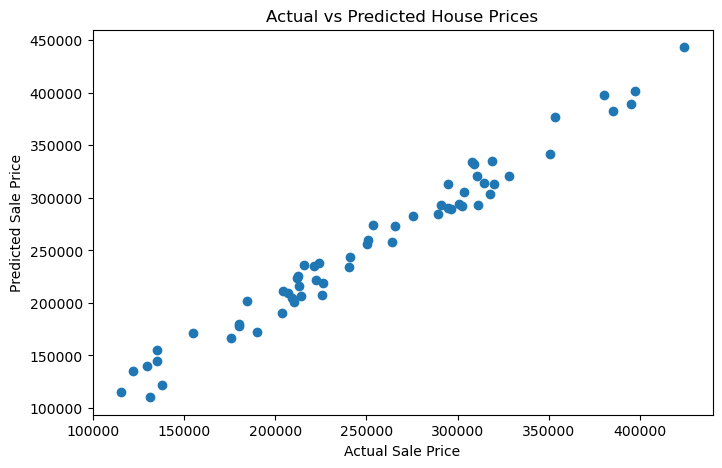

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

## Prediction Error Distribution

Prediction error is the difference between the actual
house price and the predicted house price.

This graph helps us understand how the model's errors
are distributed.

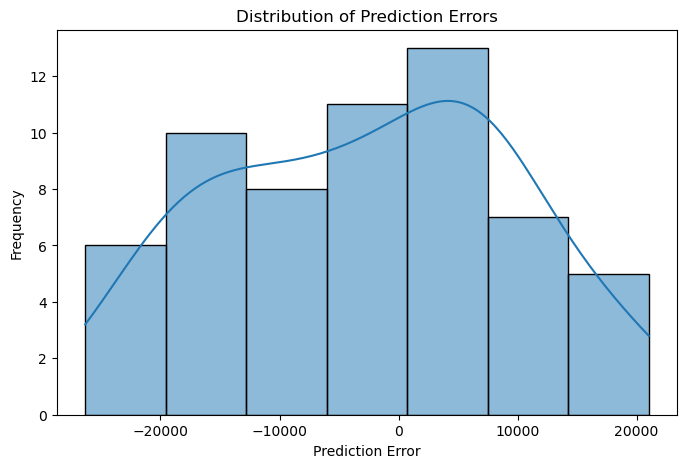

In [32]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.histplot(errors, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

# 🏠 Predicting the Price of a New House

We will provide information about a new house to the trained
Machine Learning model.

Example:

- Overall Quality = 7
- Living Area = 1800 sq ft
- Garage Capacity = 2 cars
- Basement Area = 1000 sq ft
- Year Built = 2005
- Full Bathrooms = 2
- Total Rooms = 7

The trained model will use these features to estimate
the selling price.

In [34]:
new_house = pd.DataFrame({
    "OverallQual": [7],
    "GrLivArea": [1800],
    "GarageCars": [2],
    "TotalBsmtSF": [1000],
    "YearBuilt": [2005],
    "FullBath": [2],
    "BedroomAbvGr": [7]
})

predicted_price = model.predict(new_house)

print("Predicted House Price: $", round(predicted_price[0], 2))

Predicted House Price: $ 284519.25


## Regression Coefficients

The coefficients show how the selected features are represented
in the Linear Regression model.

A positive coefficient means that, within the model,
an increase in that feature is associated with an increase
in the predicted house price, while a negative coefficient
indicates the opposite direction.

These are model-based relationships and should not be interpreted
as proof that a feature directly causes a change in house price.

In [35]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,GarageCars,19098.306423
0,OverallQual,11927.179583
5,FullBath,11084.435427
6,BedroomAbvGr,4817.860054
4,YearBuilt,743.457802
1,GrLivArea,55.429544
3,TotalBsmtSF,25.202920


## Model R² Score in Percentage

The R² score can also be represented as a percentage.

This gives an easy-to-understand interpretation of how much
variation in house prices is explained by the model.

In [36]:
accuracy_percentage = r2 * 100

print("R² Score:", r2)
print("Explained Variation:", round(accuracy_percentage, 2), "%")

R² Score: 0.9726703004838801
Explained Variation: 97.27 %


## Prediction Comparison

This table contains three values:

- Actual Price → Original house price
- Predicted Price → Price predicted by the model
- Difference → Difference between actual and predicted price

This helps us inspect individual model predictions.

In [37]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred,
    "Difference": y_test.values - y_pred
})

comparison.head(10)

,Actual Price,Predicted Price,Difference
0,224163,238265.115874,-14102.115874
1,203881,190625.189237,13255.810763
2,380236,397820.077022,-17584.077022
3,211664,223394.729886,-11730.729886
4,122139,135412.301270,-13273.301270
5,180067,180287.606473,-220.606473
6,275810,282979.235035,-7169.235035
7,209025,204251.799372,4773.200628
8,213952,206624.377851,7327.622149
9,154885,171361.962353,-16476.962353


## Average Price Comparison

Here we compare the average actual house price with
the average price predicted by the model.

This gives us a simple overall comparison between
the actual and predicted values.

In [38]:
print("Average Actual Price:", round(y_test.mean(), 2))
print("Average Predicted Price:", round(y_pred.mean(), 2))

Average Actual Price: 252167.33
Average Predicted Price: 254812.31


## Residual Analysis

A residual is the difference between the actual value
and the predicted value.

Residual = Actual Price - Predicted Price

Residual analysis helps us understand the errors made
by the Regression model.

## Residual Plot

The residual plot shows the prediction errors against
the predicted house prices.

A useful regression model generally has residuals distributed
around zero without a clear systematic pattern.

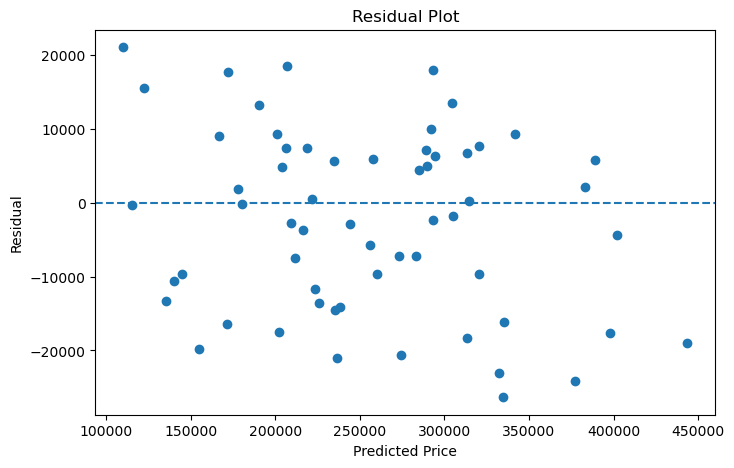

In [39]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

## Saving Prediction Results

We save the actual prices, predicted prices, and prediction
differences into a CSV file.

This allows us to use the results later for further analysis
or reporting.

In [40]:
comparison.to_csv(
    "house_price_predictions.csv",
    index=False
)

print("Prediction results saved successfully.")

Prediction results saved successfully.


## Saving the Machine Learning Model

The trained Linear Regression model is saved as a `.pkl` file.

The saved model can later be loaded and used to predict
house prices without training the model again.

In [41]:
import joblib

joblib.dump(model, "house_price_model.pkl")

print("Model saved successfully.")

Model saved successfully.


## Loading the Saved Model

We load the previously saved model and use it to make
a new prediction.

This demonstrates how a trained Machine Learning model
can be reused later.

In [42]:
loaded_model = joblib.load("house_price_model.pkl")

new_prediction = loaded_model.predict(new_house)

print("Predicted House Price: $", round(new_prediction[0], 2))

Predicted House Price: $ 284519.25


## Conclusion

In this project, we developed a **House Price Prediction** model using Machine Learning.

The project followed the complete Machine Learning process, including **data loading, data cleaning, exploratory data analysis, visualization, feature selection, data preprocessing, model training, prediction, and evaluation**.

We used **Linear Regression**, a supervised learning algorithm, to predict house prices based on features such as **overall quality, living area, garage capacity, basement area, year built, number of bathrooms, and number of rooms**.

The model was evaluated using **MAE, MSE, RMSE, and R² Score** to understand its prediction performance.

We also compared the **actual and predicted house prices**, analyzed prediction errors using residuals, and tested the model with a new house example.

Overall, this project helped us understand how **Regression Machine Learning can be used to predict continuous values such as house prices** and how different property features can influence the predicted price.


In [ ]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "FullBath",
    "BedroomAbvGr"
]

X = data[features]

y = data["SalePrice"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0            7       1560           0         1658       1969         2   
1            4       2827           2         1319       2012         3   
2            8       3920           0          841       2010         1   
3            5       3044           0         1058       1998         0   
4            7        801           1         2428       2020         0   

   BedroomAbvGr  
0             1  
1             4  
2             4  
3             4  
4             1  

Target:
0    177106
1    301044
2    360609
3    240556
4    193656
Name: SalePrice, dtype: int64
